# MScFE 622 Stochastic Modeling - Group Work Project 2

This notebook uses daily adjusted close data for TLT, GLD, SPY, and VIX. Step 2 considers both candidate approaches in the assignment: a quantile-based Markov chain and Gaussian Hidden Markov Models. The model is selected in Step 3 before it is used for the allocation rule and backtest.

The exact Yahoo Finance download is stored beside the notebook as `yfinance_adjusted_close_raw.csv`.

## Setup

Import the numerical, table, and plotting tools used in the analysis and define a consistent visual style.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "TLT": "#2F5597",
    "GLD": "#C69214",
    "SPY": "#3A7D44",
    "VIX": "#4B4453",
    "Low change": "#2B83BA",
    "Medium change": "#FDAE61",
    "High change": "#D7191C",
}

PROJECT_ROOT = Path.cwd()
RAW_DATA_FILE = PROJECT_ROOT / "yfinance_adjusted_close_raw.csv"
CLEAN_DATA_FILE = PROJECT_ROOT / "step1_clean_data.csv"

ETF_TICKERS = ["TLT", "GLD", "SPY"]
YAHOO_TO_COLUMN = {"TLT": "TLT", "GLD": "GLD", "SPY": "SPY", "^VIX": "VIX"}

print("Working folder located; all CSV files are saved beside the notebook.")
print(f"Raw data file: {RAW_DATA_FILE.name}")

Working folder located; all CSV files are saved beside the notebook.
Raw data file: yfinance_adjusted_close_raw.csv


# Step 1 - Data Preparation and Exploration

## 1.1 Obtain and preserve adjusted close prices

Download daily adjusted close prices for TLT, GLD, SPY, and VIX from Yahoo Finance.

Keep the acquisition step separate from the analysis. Each ticker is requested with its maximum available history because the assets began trading on different dates. The four individual histories are then joined by date and saved as one raw CSV. Missing values are deliberately retained in this raw file; they show where a series did not yet exist.

In [2]:
def download_adjusted_closes(ticker_map):
    # Download maximum available adjusted close history, one ticker at a time.
    import yfinance as yf

    downloaded = {}
    for yahoo_ticker, output_name in ticker_map.items():
        history = yf.Ticker(yahoo_ticker).history(
            period="max",
            auto_adjust=False,
            actions=False,
        )
        if history.empty:
            raise RuntimeError(f"Yahoo Finance returned no data for {yahoo_ticker}.")

        price_column = "Adj Close" if "Adj Close" in history.columns else "Close"
        series = history[price_column].copy()
        series.index = pd.to_datetime(series.index).tz_localize(None)
        downloaded[output_name] = series

    result = pd.concat(downloaded, axis=1).sort_index()
    result.index.name = "Date"
    return result



if not RAW_DATA_FILE.exists():
    raise FileNotFoundError(
        f"{RAW_DATA_FILE.name} is missing. Place it beside the notebook or set "
        "REFRESH_FROM_YAHOO = True."
    )
all_prices = pd.read_csv(RAW_DATA_FILE, parse_dates=["Date"], index_col="Date")
all_prices = all_prices[["TLT", "GLD", "SPY", "VIX"]].sort_index()
data_source_message = "Loaded the preserved Yahoo Finance snapshot supplied with the notebook."

coverage = pd.DataFrame(
    {
        "First valid date": all_prices.apply(lambda s: s.first_valid_index()),
        "Last valid date": all_prices.apply(lambda s: s.last_valid_index()),
        "Valid observations": all_prices.count(),
        "Missing observations in raw union": all_prices.isna().sum(),
    }
)

print(data_source_message)
print(f"Raw table shape: {all_prices.shape[0]:,} dates x {all_prices.shape[1]} series")
display(coverage)

Loaded the preserved Yahoo Finance snapshot supplied with the notebook.
Raw table shape: 9,224 dates x 4 series


,First valid date,Last valid date,Valid observations,Missing observations in raw union
TLT,2002-07-30,2026-08-17,6051,3173
GLD,2004-11-18,2026-08-17,5469,3755
SPY,1993-01-29,2026-08-17,8444,780
VIX,1990-01-02,2026-08-17,9224,0


### Why the common sample begins with GLD

SPY and VIX have histories starting before TLT, while GLD has the latest inception date of the four series. Therefore, the maximum common sample cannot begin until GLD has data. We determine the exact common start and end dates directly from the downloaded table rather than typing dates manually.

In [3]:
common_prices = all_prices.dropna(how="any").copy()

common_summary = pd.DataFrame(
    {
        "Value": [
            common_prices.index.min().date(),
            common_prices.index.max().date(),
            len(common_prices),
            int(common_prices.isna().sum().sum()),
        ]
    },
    index=[
        "Common sample start",
        "Common sample end",
        "Common price observations",
        "Missing values after alignment",
    ],
)

display(common_summary)
display(common_prices.head())

,Value
Common sample start,2004-11-18
Common sample end,2026-08-17
Common price observations,5469
Missing values after alignment,0


,TLT,GLD,SPY,VIX
Date,,,,
2004-11-18,43.650970,44.380001,79.745255,12.980000
2004-11-19,43.302582,44.779999,78.858749,13.500000
2004-11-22,43.528255,44.950001,79.234856,12.970000
2004-11-23,43.582272,44.750000,79.355736,12.670000
2004-11-24,43.582272,45.049999,79.543800,12.720000


## 1.2 Calculate returns and the daily VIX change

Prices for different assets are not directly comparable because their units differ. A log-return measures the proportional one-day price movement and can be added across time. For an ETF price $P_t$,

$$r_t = \ln(P_t/P_{t-1}).$$

For VIX, we use the point change requested in the assignment:

$$\Delta VIX_t = VIX_t - VIX_{t-1}.$$

The first common date has no preceding common observation, so it becomes missing after taking a return/change and is removed once. The resulting table is the model-ready dataset.

In [4]:
etf_log_returns = np.log(common_prices[ETF_TICKERS] / common_prices[ETF_TICKERS].shift(1))
etf_log_returns.columns = [f"{ticker}_Log_Return" for ticker in ETF_TICKERS]

vix_change = common_prices["VIX"].diff().rename("VIX_Change")

clean_data = pd.concat(
    [
        common_prices.add_suffix("_Adj_Close"),
        etf_log_returns,
        vix_change,
    ],
    axis=1,
).dropna(how="any")

clean_data.to_csv(CLEAN_DATA_FILE, float_format="%.10f")

quality_check = pd.DataFrame(
    {
        "Value": [
            clean_data.index.min().date(),
            clean_data.index.max().date(),
            len(clean_data),
            clean_data.index.is_unique,
            clean_data.index.is_monotonic_increasing,
            int(clean_data.isna().sum().sum()),
        ]
    },
    index=[
        "Clean sample start",
        "Clean sample end",
        "Clean observations",
        "Dates are unique",
        "Dates are chronological",
        "Remaining missing values",
    ],
)

print(f"Saved clean Step 1 data to: {CLEAN_DATA_FILE.name}")
display(quality_check)
display(clean_data.head())

Saved clean Step 1 data to: step1_clean_data.csv


,Value
Clean sample start,2004-11-19
Clean sample end,2026-08-17
Clean observations,5468
Dates are unique,True
Dates are chronological,True
Remaining missing values,0


,TLT_Adj_Close,GLD_Adj_Close,SPY_Adj_Close,VIX_Adj_Close,TLT_Log_Return,GLD_Log_Return,SPY_Log_Return,VIX_Change
Date,,,,,,,,
2004-11-19,43.302582,44.779999,78.858749,13.500000,-0.008013,0.008973,-0.011179,0.520000
2004-11-22,43.528255,44.950001,79.234856,12.970000,0.005198,0.003789,0.004758,-0.530000
2004-11-23,43.582272,44.750000,79.355736,12.670000,0.001240,-0.004459,0.001524,-0.300000
2004-11-24,43.582272,45.049999,79.543800,12.720000,0.000000,0.006682,0.002367,0.050000
2004-11-26,43.297729,45.290001,79.483360,12.780000,-0.006550,0.005313,-0.000760,0.059999


## 1.3 Descriptive checks

We want to verify that each transformed series has a plausible center and spread before modeling. Returns should generally be near zero on a daily basis, while VIX changes can have much larger positive and negative spikes. These checks can reveal unit mistakes or an incorrectly selected price column.

In [5]:
analysis_columns = [f"{ticker}_Log_Return" for ticker in ETF_TICKERS] + ["VIX_Change"]
descriptive_statistics = clean_data[analysis_columns].describe().T
display(descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
TLT_Log_Return,"5,468.000000",0.000114,0.009153,-0.069011,-0.005298,0.000427,0.005453,0.072503
GLD_Log_Return,"5,468.000000",0.000405,0.011495,-0.108412,-0.005154,0.000588,0.006348,0.106974
SPY_Log_Return,"5,468.000000",0.000415,0.011901,-0.115887,-0.003934,0.000717,0.005786,0.135577
VIX_Change,"5,468.000000",0.000404,1.901420,-18.710003,-0.720000,-0.099999,0.570000,24.860001


## 1.4 Plot ETF log-returns

The plot showing ETF returns over time follows below.

Clusters of large positive and negative returns suggest that market variability changes over time rather than remaining constant.

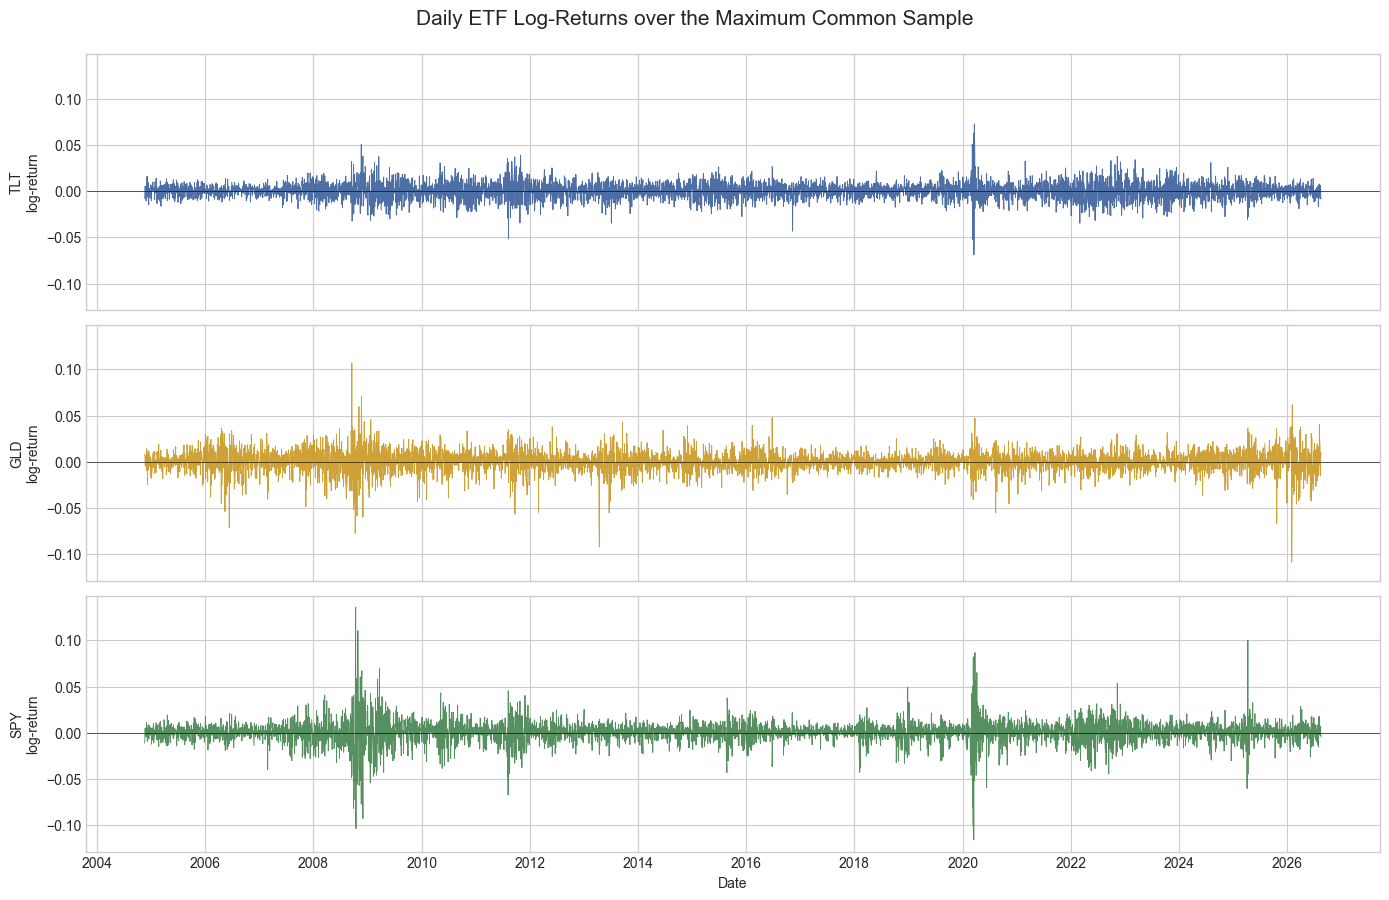

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)

for ax, ticker in zip(axes, ETF_TICKERS):
    column = f"{ticker}_Log_Return"
    ax.plot(
        clean_data.index,
        clean_data[column],
        color=COLORS[ticker],
        linewidth=0.65,
        alpha=0.85,
    )
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
    ax.set_ylabel(f"{ticker}\nlog-return")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Daily ETF Log-Returns over the Maximum Common Sample", fontsize=15, y=0.995)
fig.tight_layout()
plt.show()

**Interpretation.** All three ETF return series fluctuate around zero, which is expected for daily returns. Large movements appear in clusters, especially around market stress periods. SPY and GLD show larger maximum one-day movements than TLT in this sample, while TLT still experiences visible volatility episodes. The shared time axis confirms that the three return series are aligned before the regime analysis.

## 1.5 Plot the daily change in VIX

The plot showing $\Delta VIX$ (or VIX returns) follows below.

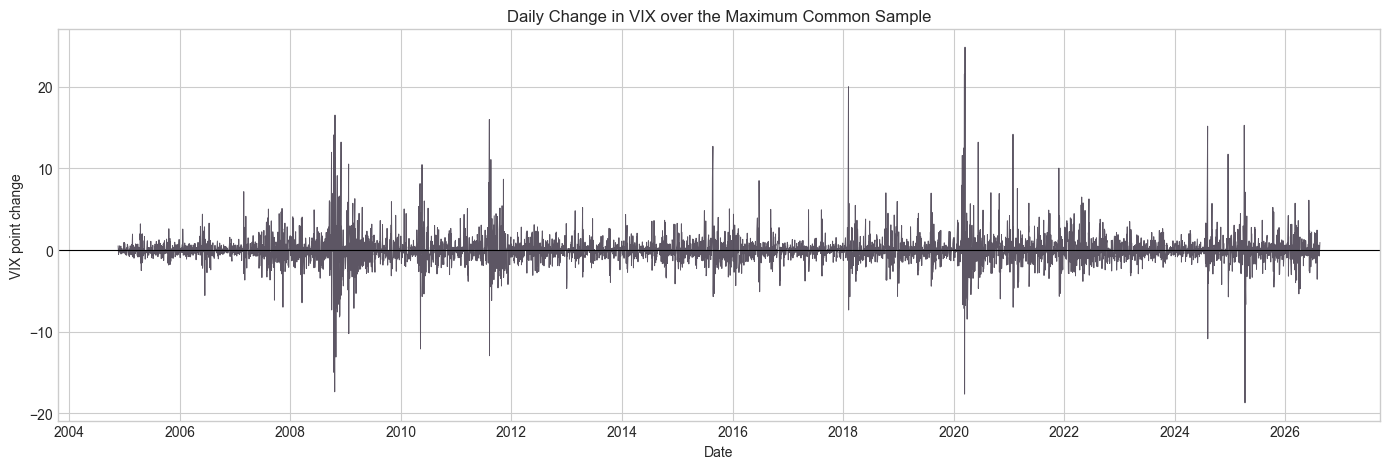

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(
    clean_data.index,
    clean_data["VIX_Change"],
    color=COLORS["VIX"],
    linewidth=0.7,
    alpha=0.9,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Daily Change in VIX over the Maximum Common Sample")
ax.set_xlabel("Date")
ax.set_ylabel("VIX point change")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

**Interpretation.** Daily VIX changes are centered close to zero but contain occasional extreme spikes. Positive spikes are especially important because they represent sudden increases in expected market volatility. The uneven, clustered pattern supports the idea that a single constant-volatility description is too simple and motivates a regime-based model.

**Step 1 conclusion.** The four price series have been aligned on their maximum common dates, all missing values have been removed from the model-ready table, and the transformations and plots are consistent with the assignment. The raw and clean data are saved as separate CSV files beside the notebook.

# Step 2 - Candidate Models for VIX Regimes

## 2A. Discrete Markov Chain

### 2A.1 Define three states using quantiles

The 33.33rd and 66.67th percentiles divide the observations into three groups of nearly equal size without imposing arbitrary fixed cutoffs:

- **Low change:** the lowest third of daily VIX changes, typically a meaningful fall in VIX.
- **Medium change:** the middle third, usually a small move near zero.
- **High change:** the highest third, typically a meaningful rise in VIX.

These labels describe the daily *change* in VIX, not the absolute VIX level. This distinction is important: a high VIX level can still fall on a given day and therefore receive the “Low change” label.

In [8]:
STATE_ORDER = ["Low change", "Medium change", "High change"]

lower_cutoff, upper_cutoff = clean_data["VIX_Change"].quantile([1 / 3, 2 / 3])

regime_data = clean_data.copy()
regime_data["VIX_State"] = pd.qcut(
    regime_data["VIX_Change"],
    q=3,
    labels=STATE_ORDER,
)

state_summary = (
    regime_data.groupby("VIX_State", observed=True)
    .agg(
        Observations=("VIX_Change", "size"),
        Mean_VIX_Change=("VIX_Change", "mean"),
        Std_VIX_Change=("VIX_Change", "std"),
        Mean_VIX_Level=("VIX_Adj_Close", "mean"),
    )
    .reindex(STATE_ORDER)
)
state_summary["Sample_Share"] = state_summary["Observations"] / len(regime_data)

print(f"33.33rd percentile cutoff: {lower_cutoff:.4f} VIX points")
print(f"66.67th percentile cutoff: {upper_cutoff:.4f} VIX points")
display(state_summary)

33.33rd percentile cutoff: -0.4700 VIX points
66.67th percentile cutoff: 0.3000 VIX points


,Observations,Mean_VIX_Change,Std_VIX_Change,Mean_VIX_Level,Sample_Share
VIX_State,,,,,
Low change,1824,-1.510795,1.449388,20.454145,0.333577
Medium change,1824,-0.091212,0.210031,15.913470,0.333577
High change,1820,1.606742,1.958662,20.936489,0.332846


**Interpretation.** The low-change state has a negative mean $\Delta VIX$, the medium state is close to zero, and the high-change state has a positive mean. The state counts are almost equal by construction because quantile cutoffs are used. The average VIX level is higher in the low- and high-change states than in the medium state, showing that large daily movements in either direction tend to occur when overall volatility is elevated.

### 2A.2 Estimate the transition matrix

A transition probability answers a simple question: “Given today's VIX-change state, what is the probability of each state on the next trading day?” The row is today's state, the column is tomorrow's state, and each row must sum to one.

For states $i$ and $j$,

$$\hat{P}_{ij}=\frac{\text{number of observed transitions from }i\text{ to }j}{\text{number of observed transitions out of }i}.$$

In [9]:
current_state = regime_data["VIX_State"].iloc[:-1].astype(str)
next_state = regime_data["VIX_State"].iloc[1:].astype(str)

transition_counts = pd.crosstab(
    current_state.to_numpy(),
    next_state.to_numpy(),
).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)

transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
transition_matrix.index.name = "Current state"
transition_matrix.columns.name = "Next state"

print("Observed transition counts")
display(transition_counts)
print("Estimated transition matrix")
display(transition_matrix)
print("Row-sum check")
display(transition_matrix.sum(axis=1).rename("Row sum").to_frame())

Observed transition counts
Estimated transition matrix
Row-sum check


Next state,Low change,Medium change,High change
Current state,,,
Low change,637,556,631
Medium change,427,783,614
High change,760,485,574


Next state,Low change,Medium change,High change
Current state,,,
Low change,0.349232,0.304825,0.345943
Medium change,0.234101,0.429276,0.336623
High change,0.417812,0.266630,0.315558


,Row sum
Current state,
Low change,1.000000
Medium change,1.000000
High change,1.000000


A diagonal entry is the probability that the same state continues on the next day. An off-diagonal entry is the probability of moving to a different state. In this sample, the medium-change state is the most persistent. After a high-change day, a move to the low-change state is more common than another high-change day, which is consistent with short-run mean reversion in daily VIX changes.

### 2A.3 Calculate the stationary distribution


 The stationary distribution is the long-run fraction of time implied by the estimated transition matrix. It is a probability vector $\pi$ satisfying

$$\pi = \pi P, \qquad \sum_i \pi_i = 1.$$

It describes the model's long-run state balance if the estimated transition behavior remains stable. It is not a forecast that tomorrow must have these probabilities.

In [10]:
eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.to_numpy().T)
stationary_index = np.argmin(np.abs(eigenvalues - 1))
stationary_values = np.real(eigenvectors[:, stationary_index])

# Eigenvectors can be returned with either sign; normalize to non-negative probabilities.
if stationary_values.sum() < 0:
    stationary_values = -stationary_values
stationary_values = stationary_values / stationary_values.sum()

stationary_distribution = pd.Series(
    stationary_values,
    index=STATE_ORDER,
    name="Stationary probability",
)
observed_distribution = (
    regime_data["VIX_State"].value_counts(normalize=True).reindex(STATE_ORDER)
)

distribution_comparison = pd.concat(
    [
        stationary_distribution,
        observed_distribution.rename("Observed sample share"),
    ],
    axis=1,
)

display(distribution_comparison)
print(f"Stationary probabilities sum to {stationary_distribution.sum():.6f}.")

Stationary probabilities sum to 1.000000.


,Stationary probability,Observed sample share
Low change,0.333638,0.333577
Medium change,0.333638,0.333577
High change,0.332724,0.332846


**Interpretation.** The stationary probabilities are close to one-third for each state. This is expected because the states were created from sample terciles, although the stationary distribution is determined by the sequence of transitions rather than by the state counts alone. The close match between the stationary probabilities and observed sample shares is a useful consistency check.

### 2A.4 Plot VIX with color-coded states

The gray line shows the VIX level. Each colored point shows the state assigned from that day's VIX change. This connects the transition model's categories to the familiar VIX time series.

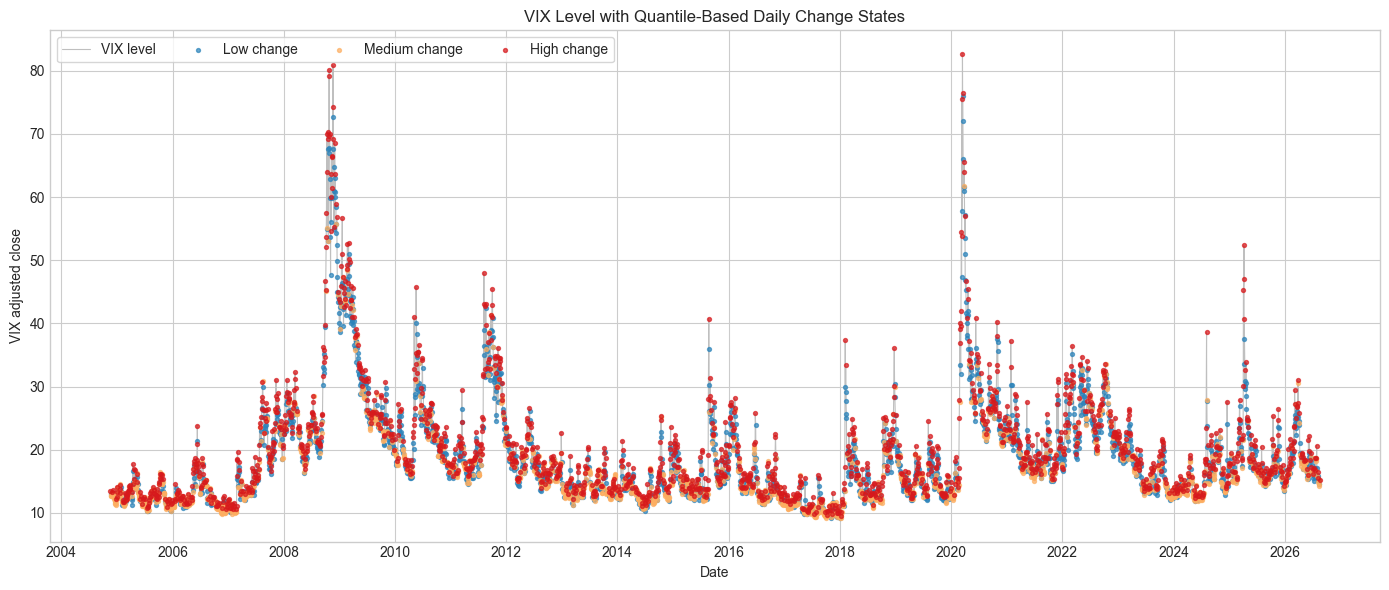

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    regime_data.index,
    regime_data["VIX_Adj_Close"],
    color="0.75",
    linewidth=0.8,
    label="VIX level",
    zorder=1,
)

for state in STATE_ORDER:
    mask = regime_data["VIX_State"] == state
    ax.scatter(
        regime_data.index[mask],
        regime_data.loc[mask, "VIX_Adj_Close"],
        s=8,
        alpha=0.70,
        color=COLORS[state],
        label=state,
        zorder=2,
    )

ax.set_title("VIX Level with Quantile-Based Daily Change States")
ax.set_xlabel("Date")
ax.set_ylabel("VIX adjusted close")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(ncol=4, frameon=True, loc="upper left")
fig.tight_layout()
plt.show()

**Discrete Markov Chain summary.** The quantile method gives a clear transition matrix and stationary distribution. It is easy to reproduce, but the state colors change frequently because the categories describe one-day changes in VIX rather than persistent volatility conditions. This model remains a useful benchmark for the HMM candidates below.

## 2B. Gaussian Hidden Markov Models

The second approach treats the VIX-change regime as hidden. Each state has its own Gaussian mean and variance, while a transition matrix describes how states evolve over time. We fit both two-state and three-state models with the EM algorithm, as required in the assignment.

The helper functions below implement the forward-backward calculations, EM updates, smoothed probabilities, and Viterbi state sequence. Keeping the implementation in the notebook makes the calculation reproducible without an additional HMM package.

In [12]:
from scipy.special import logsumexp
from sklearn.mixture import GaussianMixture


def emission_log_density(x, means, variances):
    return -0.5 * (
        np.log(2 * np.pi * variances)[None, :]
        + (x[:, None] - means[None, :]) ** 2 / variances[None, :]
    )


def forward_backward(x, startprob, transmat, means, variances):
    small = 1e-300
    log_start = np.log(np.clip(startprob, small, None))
    log_trans = np.log(np.clip(transmat, small, None))
    log_emit = emission_log_density(x, means, variances)
    n_obs, n_states = log_emit.shape

    log_alpha = np.empty((n_obs, n_states))
    log_alpha[0] = log_start + log_emit[0]
    for t in range(1, n_obs):
        log_alpha[t] = log_emit[t] + logsumexp(
            log_alpha[t - 1][:, None] + log_trans, axis=0
        )
    log_likelihood = logsumexp(log_alpha[-1])

    log_beta = np.zeros((n_obs, n_states))
    for t in range(n_obs - 2, -1, -1):
        log_beta[t] = logsumexp(
            log_trans + log_emit[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1,
        )

    smoothed = np.exp(log_alpha + log_beta - log_likelihood)
    smoothed /= smoothed.sum(axis=1, keepdims=True)
    filtered = np.exp(log_alpha - logsumexp(log_alpha, axis=1, keepdims=True))

    log_xi = (
        log_alpha[:-1, :, None]
        + log_trans[None, :, :]
        + log_emit[1:, None, :]
        + log_beta[1:, None, :]
        - log_likelihood
    )
    expected_transitions = np.exp(log_xi).sum(axis=0)
    return log_likelihood, smoothed, filtered, expected_transitions


def viterbi_path(x, startprob, transmat, means, variances):
    small = 1e-300
    log_start = np.log(np.clip(startprob, small, None))
    log_trans = np.log(np.clip(transmat, small, None))
    log_emit = emission_log_density(x, means, variances)
    n_obs, n_states = log_emit.shape

    scores = np.empty((n_obs, n_states))
    backpointers = np.zeros((n_obs, n_states), dtype=int)
    scores[0] = log_start + log_emit[0]

    for t in range(1, n_obs):
        candidates = scores[t - 1][:, None] + log_trans
        backpointers[t] = np.argmax(candidates, axis=0)
        scores[t] = log_emit[t] + candidates[backpointers[t], np.arange(n_states)]

    path = np.zeros(n_obs, dtype=int)
    path[-1] = np.argmax(scores[-1])
    for t in range(n_obs - 2, -1, -1):
        path[t] = backpointers[t + 1, path[t + 1]]
    return path


def fit_gaussian_hmm(values, n_states, n_init=3, max_iter=250, tolerance=1e-5):
    original = np.asarray(values, dtype=float)
    center = original.mean()
    scale = original.std(ddof=0)
    x = (original - center) / scale
    n_obs = len(x)
    best = None

    for seed in range(n_init):
        mixture = GaussianMixture(
            n_components=n_states,
            covariance_type="diag",
            n_init=1,
            random_state=seed,
            reg_covar=1e-4,
        ).fit(x[:, None])
        initial_states = mixture.predict(x[:, None])
        means = mixture.means_.ravel()
        variances = mixture.covariances_.reshape(-1).clip(1e-4)

        startprob = np.bincount(
            initial_states[:20], minlength=n_states
        ).astype(float) + 1.0
        startprob /= startprob.sum()

        transition_counts = np.ones((n_states, n_states))
        np.add.at(
            transition_counts,
            (initial_states[:-1], initial_states[1:]),
            1,
        )
        transmat = transition_counts / transition_counts.sum(axis=1, keepdims=True)

        previous_log_likelihood = -np.inf
        for iteration in range(max_iter):
            log_likelihood, smoothed, filtered, expected_transitions = forward_backward(
                x, startprob, transmat, means, variances
            )

            weights = smoothed.sum(axis=0).clip(1e-10)
            startprob = smoothed[0] + 1e-6
            startprob /= startprob.sum()
            transmat = expected_transitions + 1e-6
            transmat /= transmat.sum(axis=1, keepdims=True)
            means = (smoothed * x[:, None]).sum(axis=0) / weights
            variances = (
                smoothed * (x[:, None] - means[None, :]) ** 2
            ).sum(axis=0) / weights
            variances = variances.clip(1e-4)

            if abs(log_likelihood - previous_log_likelihood) < tolerance:
                break
            previous_log_likelihood = log_likelihood

        log_likelihood, smoothed, filtered, _ = forward_backward(
            x, startprob, transmat, means, variances
        )
        if best is None or log_likelihood > best["scaled_log_likelihood"]:
            best = {
                "scaled_log_likelihood": log_likelihood,
                "startprob": startprob.copy(),
                "transmat": transmat.copy(),
                "means_scaled": means.copy(),
                "variances_scaled": variances.copy(),
                "smoothed_probabilities": smoothed.copy(),
                "filtered_probabilities": filtered.copy(),
                "iterations": iteration + 1,
            }

    path = viterbi_path(
        x,
        best["startprob"],
        best["transmat"],
        best["means_scaled"],
        best["variances_scaled"],
    )

    order = np.argsort(best["variances_scaled"])
    old_to_new = np.empty(n_states, dtype=int)
    old_to_new[order] = np.arange(n_states)

    best["viterbi_states"] = old_to_new[path]
    best["startprob"] = best["startprob"][order]
    best["transmat"] = best["transmat"][np.ix_(order, order)]
    best["means"] = center + scale * best["means_scaled"][order]
    best["variances"] = scale**2 * best["variances_scaled"][order]
    best["smoothed_probabilities"] = best["smoothed_probabilities"][:, order]
    best["filtered_probabilities"] = best["filtered_probabilities"][:, order]
    best["log_likelihood"] = best["scaled_log_likelihood"] - n_obs * np.log(scale)
    best["n_parameters"] = n_states**2 + 2 * n_states - 1
    best["aic"] = 2 * best["n_parameters"] - 2 * best["log_likelihood"]
    best["bic"] = np.log(n_obs) * best["n_parameters"] - 2 * best["log_likelihood"]
    return best


def hmm_state_labels(n_states):
    if n_states == 2:
        return ["Calm", "Turbulent"]
    return ["Calm", "Active", "Turbulent"]

### 2B.1 Fit the two HMM candidates

Three deterministic starting values are tried for each model. The best converged likelihood is kept, which reduces the chance that EM stops at a poor local solution. States are ordered by the standard deviation of their VIX changes, so the labels run from calm to turbulent.

In [13]:
vix_observations = clean_data["VIX_Change"].to_numpy()
hmm_models = {
    n_states: fit_gaussian_hmm(vix_observations, n_states=n_states)
    for n_states in (2, 3)
}

parameter_rows = []
for n_states, model in hmm_models.items():
    labels = hmm_state_labels(n_states)
    counts = np.bincount(model["viterbi_states"], minlength=n_states)
    for state_number, label in enumerate(labels):
        parameter_rows.append(
            {
                "Model": f"{n_states}-state HMM",
                "State": label,
                "Mean VIX change": model["means"][state_number],
                "Std. VIX change": np.sqrt(model["variances"][state_number]),
                "Starting probability": model["startprob"][state_number],
                "Viterbi observations": counts[state_number],
            }
        )

hmm_parameter_table = pd.DataFrame(parameter_rows).set_index(["Model", "State"])
display(hmm_parameter_table)

for n_states, model in hmm_models.items():
    labels = hmm_state_labels(n_states)
    matrix = pd.DataFrame(model["transmat"], index=labels, columns=labels)
    matrix.index.name = f"{n_states}-state HMM: current"
    matrix.columns.name = "Next state"
    display(matrix)

Mean VIX change  Std. VIX change  Starting probability  \
Model       State                                                               
2-state HMM Calm             -0.074342         0.810516              0.999999   
            Turbulent         0.213231         3.460548              0.000001   
3-state HMM Calm             -0.061966         0.619937              0.999998   
            Active           -0.011947         1.762858              0.000001   
            Turbulent         0.658817         6.022309              0.000001   

                       Viterbi observations  
Model       State                            
2-state HMM Calm                       4162  
            Turbulent                  1306  
3-state HMM Calm                       2901  
            Active                     2308  
            Turbulent                   259

Next state,Calm,Turbulent
2-state HMM: current,,
Calm,0.958852,0.041148
Turbulent,0.117117,0.882883


Next state,Calm,Active,Turbulent
3-state HMM: current,,,
Calm,0.939508,0.059101,0.001391
Active,0.074528,0.909801,0.015671
Turbulent,0.000000,0.128232,0.871768


The HMM states are mainly separated by the size of VIX movements rather than by a large difference in average direction. In the three-state model, the calm state contains small daily changes, the active state contains wider moves, and the turbulent state captures the most extreme changes. The diagonal transition probabilities are high, so these regimes are more persistent than the daily quantile categories.

### 2B.2 Most likely state sequences

The Viterbi sequence gives one most likely state for every date. Plotting both candidates shows what is gained when the third state is added.

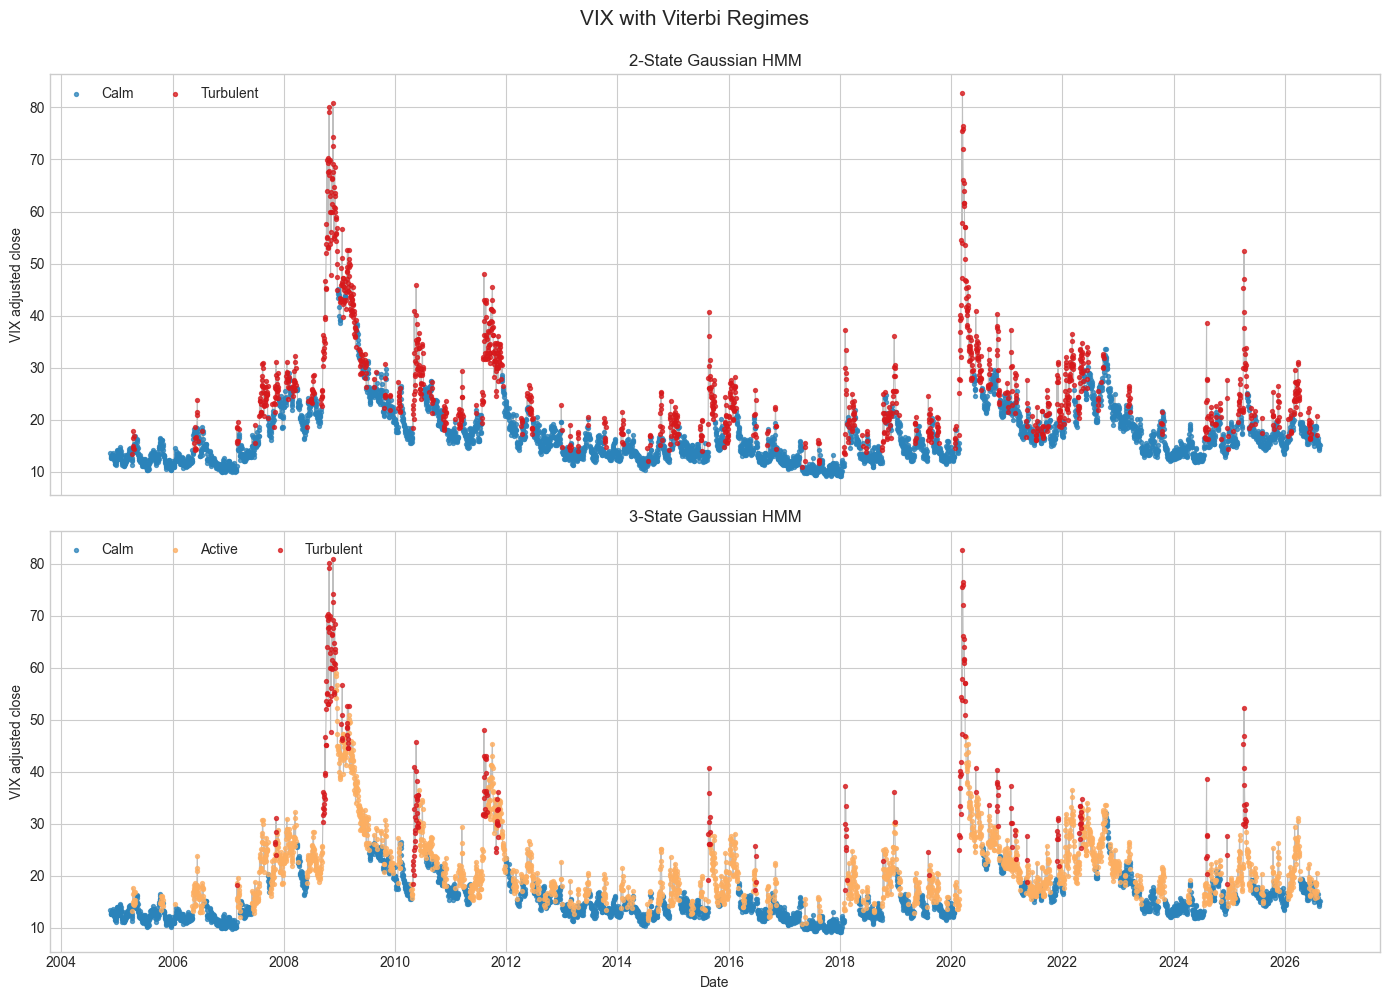

In [14]:
HMM_COLORS = {
    2: {"Calm": "#2B83BA", "Turbulent": "#D7191C"},
    3: {"Calm": "#2B83BA", "Active": "#FDAE61", "Turbulent": "#D7191C"},
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

for ax, n_states in zip(axes, (2, 3)):
    model = hmm_models[n_states]
    labels = hmm_state_labels(n_states)
    state_sequence = pd.Series(model["viterbi_states"], index=clean_data.index)

    ax.plot(
        clean_data.index,
        clean_data["VIX_Adj_Close"],
        color="0.75",
        linewidth=0.8,
        zorder=1,
    )
    for state_number, label in enumerate(labels):
        mask = state_sequence == state_number
        ax.scatter(
            clean_data.index[mask],
            clean_data.loc[mask, "VIX_Adj_Close"],
            s=8,
            alpha=0.75,
            color=HMM_COLORS[n_states][label],
            label=label,
            zorder=2,
        )
    ax.set_title(f"{n_states}-State Gaussian HMM")
    ax.set_ylabel("VIX adjusted close")
    ax.legend(ncol=n_states, loc="upper left")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("VIX with Viterbi Regimes", fontsize=15, y=0.995)
fig.tight_layout()
plt.show()

### 2B.3 Smoothed state probabilities

The smoothed probabilities use the full sample to estimate the probability of each state on each date. They show uncertainty that is hidden when only the single Viterbi state is reported.

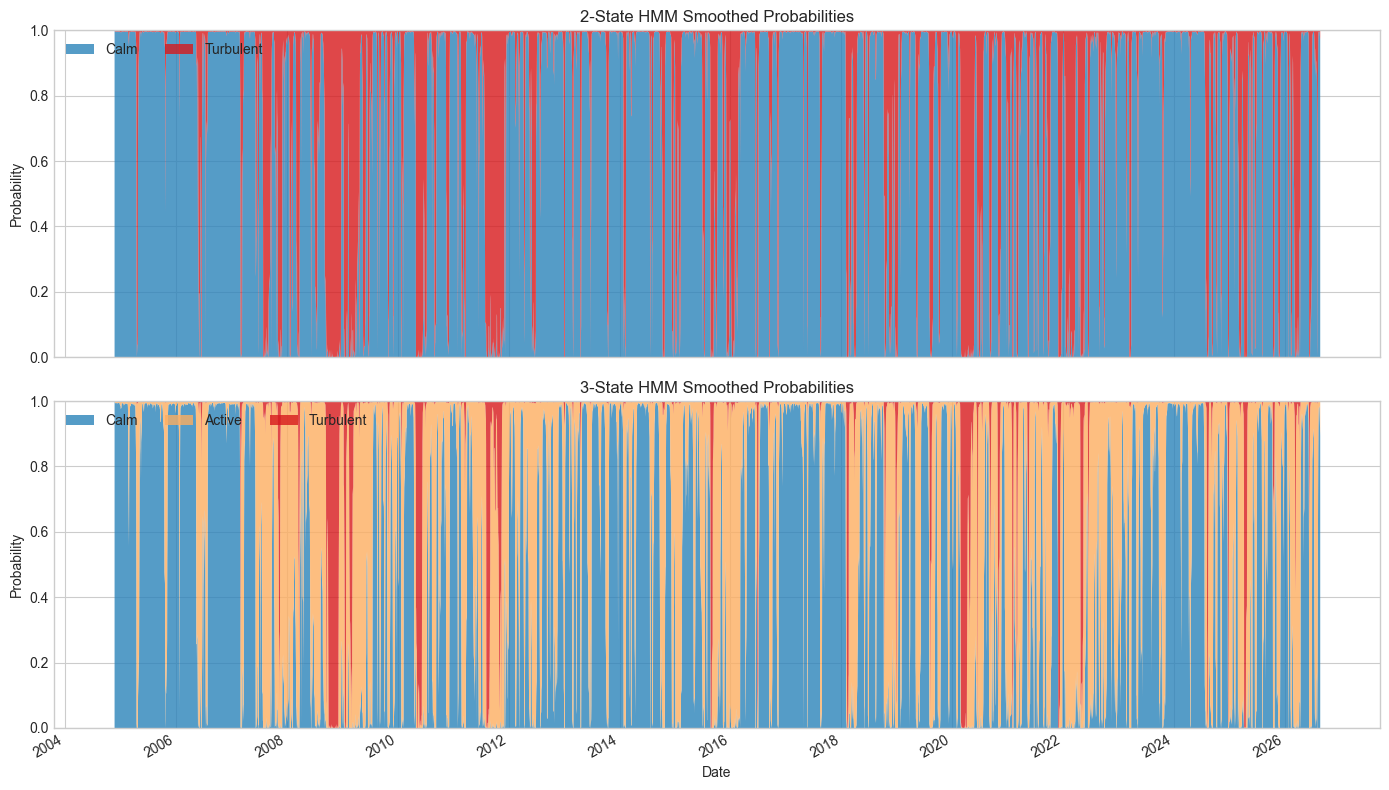

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, n_states in zip(axes, (2, 3)):
    labels = hmm_state_labels(n_states)
    probabilities = pd.DataFrame(
        hmm_models[n_states]["smoothed_probabilities"],
        index=clean_data.index,
        columns=labels,
    )
    probabilities.plot.area(
        ax=ax,
        stacked=True,
        color=[HMM_COLORS[n_states][label] for label in labels],
        alpha=0.80,
        linewidth=0,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probability")
    ax.set_title(f"{n_states}-State HMM Smoothed Probabilities")
    ax.legend(ncol=n_states, loc="upper left")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

# Step 3 - State Selection and Interpretation

## 3.1 Compare the candidate models

AIC and BIC reward a higher likelihood but penalize extra parameters. Lower values are preferred. The HMM rows use the observed likelihood of the continuous VIX-change series.

The original Markov chain is fitted to categories, so its categorical likelihood is not directly comparable with a continuous Gaussian likelihood. For the table, a Gaussian distribution is added within each quantile state and the likelihood is evaluated on the same continuous VIX-change series. This gives a useful common-scale diagnostic, but the Markov-chain AIC and BIC remain approximate because its states were fixed by sample quantiles rather than estimated by likelihood maximization.

In [16]:
def quantile_mc_information_criteria(values, state_codes, n_states):
    original = np.asarray(values, dtype=float)
    center = original.mean()
    scale = original.std(ddof=0)
    x = (original - center) / scale
    states = np.asarray(state_codes, dtype=int)

    startprob = np.bincount(states, minlength=n_states).astype(float)
    startprob /= startprob.sum()
    counts = np.ones((n_states, n_states)) * 1e-6
    np.add.at(counts, (states[:-1], states[1:]), 1)
    transmat = counts / counts.sum(axis=1, keepdims=True)
    means = np.array([x[states == state].mean() for state in range(n_states)])
    variances = np.array([x[states == state].var(ddof=0) for state in range(n_states)])
    variances = variances.clip(1e-4)

    scaled_log_likelihood, _, _, _ = forward_backward(
        x, startprob, transmat, means, variances
    )
    log_likelihood = scaled_log_likelihood - len(x) * np.log(scale)
    n_parameters = n_states**2 + 3 * n_states - 2
    aic = 2 * n_parameters - 2 * log_likelihood
    bic = np.log(len(x)) * n_parameters - 2 * log_likelihood
    return log_likelihood, n_parameters, aic, bic


mc_scores = quantile_mc_information_criteria(
    clean_data["VIX_Change"],
    regime_data["VIX_State"].cat.codes,
    n_states=3,
)

comparison_rows = [
    {
        "Method": "Quantile Markov chain",
        "States": 3,
        "Log-likelihood": mc_scores[0],
        "Parameters": mc_scores[1],
        "AIC": mc_scores[2],
        "BIC": mc_scores[3],
        "Score basis": "Continuous diagnostic (approx.)",
    }
]

for n_states, model in hmm_models.items():
    comparison_rows.append(
        {
            "Method": "Gaussian HMM",
            "States": n_states,
            "Log-likelihood": model["log_likelihood"],
            "Parameters": model["n_parameters"],
            "AIC": model["aic"],
            "BIC": model["bic"],
            "Score basis": "Observed continuous likelihood",
        }
    )

model_comparison = pd.DataFrame(comparison_rows).set_index(["Method", "States"])
display(model_comparison)

Log-likelihood  Parameters           AIC  \
Method                States                                             
Quantile Markov chain 3       -10,914.733697          16 21,861.467395   
Gaussian HMM          2        -9,313.281823           7 18,640.563647   
                      3        -8,965.293102          14 17,958.586204   

                                       BIC                      Score basis  
Method                States                                                 
Quantile Markov chain 3      21,967.174086  Continuous diagnostic (approx.)  
Gaussian HMM          2      18,686.810324   Observed continuous likelihood  
                      3      18,051.079558   Observed continuous likelihood

## 3.2 Select the preferred model

The three-state HMM has lower AIC and BIC than the two-state HMM. Its calm, active, and turbulent states also have clearly different VIX-change standard deviations. Compared with the quantile Markov chain, it produces persistent regimes instead of sorting every daily observation into a fixed bucket.

For these reasons, the **three-state Gaussian HMM** is selected. The quantile chain remains useful as a transparent benchmark, but the HMM sequence is more suitable for the allocation rule.

In [17]:
CHOSEN_STATE_COUNT = 3
CHOSEN_STATE_LABELS = hmm_state_labels(CHOSEN_STATE_COUNT)
chosen_model = hmm_models[CHOSEN_STATE_COUNT]

chosen_state_sequence = pd.Series(
    pd.Categorical.from_codes(
        chosen_model["viterbi_states"],
        categories=CHOSEN_STATE_LABELS,
        ordered=True,
    ),
    index=clean_data.index,
    name="Regime",
)

print("Selected model: three-state Gaussian HMM")
display(chosen_state_sequence.value_counts().reindex(CHOSEN_STATE_LABELS).to_frame("Observations"))

Selected model: three-state Gaussian HMM


,Observations
Regime,
Calm,2901
Active,2308
Turbulent,259


## 3.3 ETF returns by state

The table reports the mean and standard deviation of daily ETF log-returns in each selected HMM state. The bar charts use basis points for the means and percentages for the standard deviations so that the differences remain readable.

Mean daily log-return                    Daily standard deviation  \
                            TLT      GLD       SPY                      TLT   
Regime                                                                        
Calm                  -0.000169 0.000460  0.001345                 0.007429   
Active                 0.000312 0.000340 -0.000045                 0.009623   
Turbulent              0.001516 0.000363 -0.005897                 0.017993   

                             
               GLD      SPY  
Regime                       
Calm      0.009500 0.005636  
Active    0.012350 0.012373  
Turbulent 0.020531 0.034979

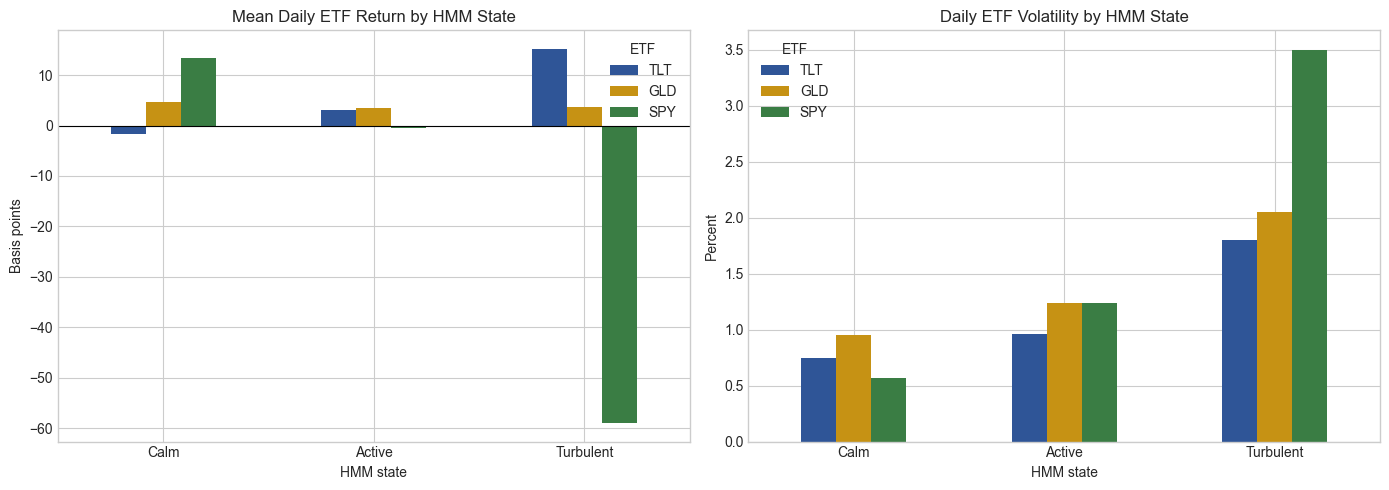

In [18]:
return_columns = [f"{ticker}_Log_Return" for ticker in ETF_TICKERS]

mean_returns_by_state = clean_data[return_columns].groupby(
    chosen_state_sequence, observed=True
).mean()
std_returns_by_state = clean_data[return_columns].groupby(
    chosen_state_sequence, observed=True
).std()

mean_returns_by_state.columns = ETF_TICKERS
std_returns_by_state.columns = ETF_TICKERS

state_return_statistics = pd.concat(
    {
        "Mean daily log-return": mean_returns_by_state,
        "Daily standard deviation": std_returns_by_state,
    },
    axis=1,
)
display(state_return_statistics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(mean_returns_by_state * 10_000).plot(
    kind="bar", ax=axes[0], color=[COLORS[ticker] for ticker in ETF_TICKERS]
)
(std_returns_by_state * 100).plot(
    kind="bar", ax=axes[1], color=[COLORS[ticker] for ticker in ETF_TICKERS]
)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean Daily ETF Return by HMM State")
axes[0].set_ylabel("Basis points")
axes[1].set_title("Daily ETF Volatility by HMM State")
axes[1].set_ylabel("Percent")
for ax in axes:
    ax.set_xlabel("HMM state")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="ETF")
fig.tight_layout()
plt.show()

SPY has the highest average return in the calm state but performs poorly in the turbulent state. GLD has the highest mean in the active state, while TLT has the highest mean in the turbulent state. Return dispersion also rises across the HMM states, especially for SPY. This pattern gives a direct economic interpretation to the regimes and provides the rule used in Step 4.

# Step 4 - Designing the Rotation Strategy

For each HMM state, the strategy invests 100% in the ETF with the highest historical mean return in that state. This is the simple rule specified in the assignment. The decision is made from the state observed on the previous day, so the position is delayed by one trading day in the backtest.

In [19]:
selected_asset_by_state = mean_returns_by_state.idxmax(axis=1)

allocation_rows = []
for state in CHOSEN_STATE_LABELS:
    selected_asset = selected_asset_by_state.loc[state]
    allocation_rows.append(
        {
            "HMM state": state,
            "Selected ETF": selected_asset,
            "Mean daily log-return (bps)": mean_returns_by_state.loc[state, selected_asset] * 10_000,
            "TLT weight": float(selected_asset == "TLT"),
            "GLD weight": float(selected_asset == "GLD"),
            "SPY weight": float(selected_asset == "SPY"),
        }
    )

allocation_table = pd.DataFrame(allocation_rows).set_index("HMM state")
display(allocation_table)

,Selected ETF,Mean daily log-return (bps),TLT weight,GLD weight,SPY weight
HMM state,,,,,
Calm,SPY,13.450967,0.000000,0.000000,1.000000
Active,GLD,3.397799,0.000000,1.000000,0.000000
Turbulent,TLT,15.163546,1.000000,0.000000,0.000000


The final rule is straightforward: hold SPY in the calm state, GLD in the active state, and TLT in the turbulent state. It moves toward equities when VIX changes are small and toward defensive assets when VIX changes become more unstable.

# Step 5 - Backtesting and Evaluation

## 5.1 Construct the strategy and benchmarks

The backtest uses simple daily returns because portfolio wealth compounds as $(1+r_t)$. The state signal is based on filtered HMM probabilities, which only use information available through that date. It is then shifted by one day before the return is earned.

The equal-weight benchmark starts each month at one-third in each ETF and allows the weights to drift until the next monthly rebalance. The second benchmark is buy-and-hold SPY. Transaction costs and taxes are not included.

In [20]:
simple_etf_returns = np.expm1(clean_data[return_columns])
simple_etf_returns.columns = ETF_TICKERS


def build_rotation_return(n_states):
    model = hmm_models[n_states]
    labels = hmm_state_labels(n_states)

    viterbi_sequence = pd.Series(
        pd.Categorical.from_codes(
            model["viterbi_states"], categories=labels, ordered=True
        ),
        index=clean_data.index,
        name="Regime",
    )
    state_means = clean_data[return_columns].groupby(
        viterbi_sequence, observed=True
    ).mean()
    state_means.columns = ETF_TICKERS
    mapping = state_means.idxmax(axis=1).to_dict()

    filtered_codes = np.argmax(model["filtered_probabilities"], axis=1)
    filtered_sequence = pd.Series(
        pd.Categorical.from_codes(
            filtered_codes, categories=labels, ordered=True
        ),
        index=clean_data.index,
        name="Filtered regime",
    )
    lagged_state = filtered_sequence.shift(1).astype(object)
    asset_signal = lagged_state.map(mapping)

    strategy_return = pd.Series(np.nan, index=clean_data.index, dtype=float)
    for asset in ETF_TICKERS:
        mask = asset_signal == asset
        strategy_return.loc[mask] = simple_etf_returns.loc[mask, asset]
    return strategy_return, mapping, filtered_sequence


def monthly_equal_weight_return(asset_returns):
    weights = np.repeat(1 / len(asset_returns.columns), len(asset_returns.columns))
    portfolio_returns = []
    current_month = None

    for date, row in asset_returns.iterrows():
        month = date.to_period("M")
        if month != current_month:
            weights = np.repeat(1 / len(weights), len(weights))
            current_month = month

        daily_asset_returns = row.to_numpy()
        portfolio_return = float(weights @ daily_asset_returns)
        portfolio_returns.append(portfolio_return)
        weights = weights * (1 + daily_asset_returns) / (1 + portfolio_return)

    return pd.Series(portfolio_returns, index=asset_returns.index)


strategy_return, strategy_mapping, filtered_state_sequence = build_rotation_return(
    CHOSEN_STATE_COUNT
)
equal_weight_return = monthly_equal_weight_return(simple_etf_returns)
spy_return = simple_etf_returns["SPY"]

comparison_returns = pd.concat(
    [
        strategy_return.rename("HMM rotation"),
        equal_weight_return.rename("Equal-weight monthly"),
        spy_return.rename("SPY buy-and-hold"),
    ],
    axis=1,
).dropna()

print(
    f"Backtest period: {comparison_returns.index.min().date()} to "
    f"{comparison_returns.index.max().date()} ({len(comparison_returns):,} trading days)"
)
display(comparison_returns.head())

Backtest period: 2004-11-22 to 2026-08-17 (5,467 trading days)


,HMM rotation,Equal-weight monthly,SPY buy-and-hold
Date,,,
2004-11-22,0.004769,0.004588,0.004769
2004-11-23,0.001526,-0.000584,0.001526
2004-11-24,0.002370,0.003037,0.002370
2004-11-26,-0.000760,-0.000621,-0.000760
2004-11-29,-0.004563,-0.004199,-0.004563


## 5.2 Performance metrics

Cumulative return measures the total gain over the sample. Annualized return and volatility use 252 trading days per year. The Sharpe ratio assumes a zero risk-free rate, and maximum drawdown is the largest decline from a previous portfolio peak.

In [21]:
TRADING_DAYS = 252


def performance_metrics(return_series):
    returns = return_series.dropna()
    wealth = (1 + returns).cumprod()
    years = len(returns) / TRADING_DAYS
    cumulative_return = wealth.iloc[-1] - 1
    annualized_return = wealth.iloc[-1] ** (1 / years) - 1
    annualized_volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe_ratio = returns.mean() / returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    drawdown = wealth / wealth.cummax() - 1

    return pd.Series(
        {
            "Cumulative Return": cumulative_return,
            "Annualized Return": annualized_return,
            "Annualized Volatility": annualized_volatility,
            "Sharpe Ratio": sharpe_ratio,
            "Maximum Drawdown": drawdown.min(),
        }
    )


performance_table = comparison_returns.apply(performance_metrics).T
display(
    performance_table.style.format(
        {
            "Cumulative Return": "{:.2%}",
            "Annualized Return": "{:.2%}",
            "Annualized Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
            "Maximum Drawdown": "{:.2%}",
        }
    )
)

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
HMM rotation,697.33%,10.04%,15.70%,0.688,-28.98%
Equal-weight monthly,542.16%,8.95%,9.72%,0.931,-23.04%
SPY buy-and-hold,879.82%,11.09%,18.88%,0.652,-55.19%


## 5.3 Cumulative performance

The chart shows the growth of one dollar. A logarithmic vertical scale keeps all three portfolios visible over the long sample.

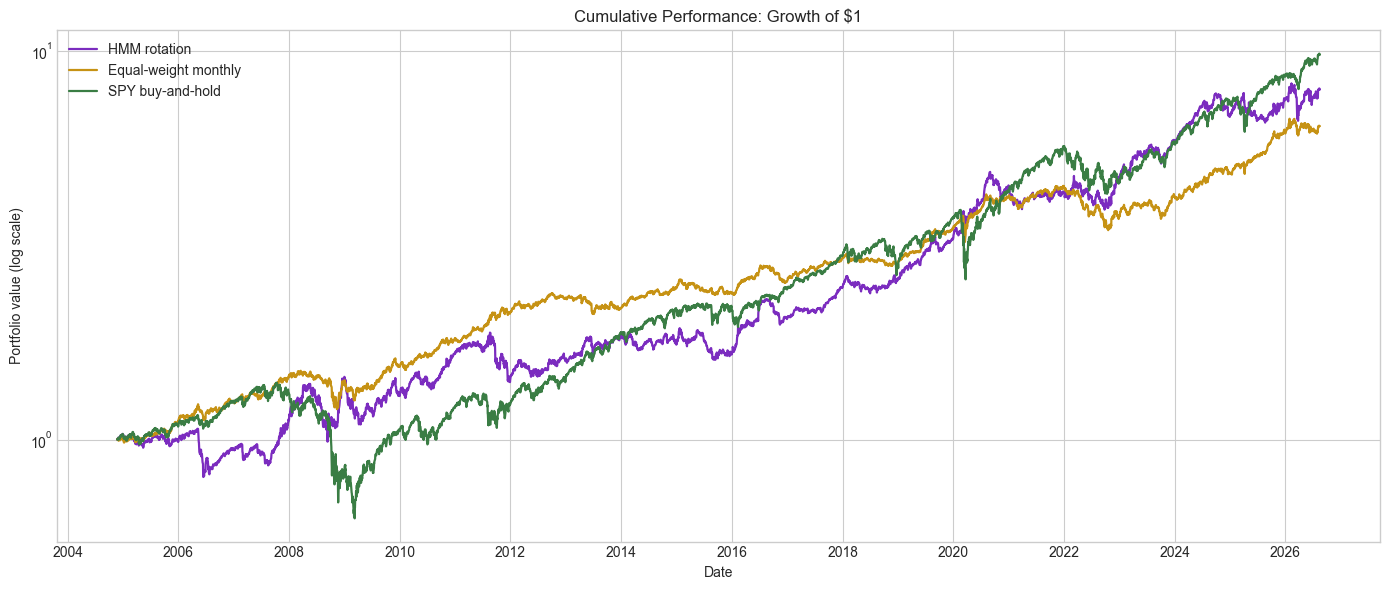

In [22]:
wealth_index = (1 + comparison_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
for column, color in zip(
    wealth_index.columns,
    ["#7B2CBF", "#C69214", "#3A7D44"],
):
    ax.plot(wealth_index.index, wealth_index[column], label=column, color=color, linewidth=1.6)

ax.set_yscale("log")
ax.set_title("Cumulative Performance: Growth of $1")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio value (log scale)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

The HMM rotation finishes between the two benchmarks. SPY has the highest cumulative and annualized return, while the equal-weight portfolio has the highest Sharpe ratio and the smallest drawdown. The HMM strategy earns a 10.04% annualized return with a 0.688 Sharpe ratio. Its maximum drawdown is 28.98%, substantially smaller than SPY's 55.19% drawdown, but not as small as the equal-weight benchmark's 23.04%.

The result is still an in-sample strategy test: the HMM parameters and the state-to-asset mapping were estimated from the full sample. A live implementation would re-estimate them through time and would also include trading costs.

## 5.4 Sensitivity to the number of states

To check whether the result depends on the selected number of states, the same allocation rule and one-day lag are applied to both the two-state and three-state HMMs.

In [23]:
two_state_return, two_state_mapping, _ = build_rotation_return(2)
three_state_return, three_state_mapping, _ = build_rotation_return(3)

sensitivity_returns = pd.concat(
    [
        two_state_return.rename("Two-state HMM rotation"),
        three_state_return.rename("Three-state HMM rotation"),
    ],
    axis=1,
).dropna()
sensitivity_table = sensitivity_returns.apply(performance_metrics).T

mapping_comparison = pd.DataFrame(
    {
        "Two-state HMM": pd.Series(two_state_mapping),
        "Three-state HMM": pd.Series(three_state_mapping),
    }
)

display(mapping_comparison.fillna("-"))
display(
    sensitivity_table.style.format(
        {
            "Cumulative Return": "{:.2%}",
            "Annualized Return": "{:.2%}",
            "Annualized Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
            "Maximum Drawdown": "{:.2%}",
        }
    )
)

,Two-state HMM,Three-state HMM
Active,-,GLD
Calm,SPY,SPY
Turbulent,TLT,TLT


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Two-state HMM rotation,407.84%,7.78%,14.93%,0.576,-32.31%
Three-state HMM rotation,697.33%,10.04%,15.70%,0.688,-28.98%


The two-state specification combines the active and turbulent observations into one broad stress state, while the three-state model separates moderate and extreme VIX activity. In this sample, the three-state strategy has a higher annualized return and Sharpe ratio, as well as a smaller maximum drawdown. The result is therefore sensitive to the number of regimes, but the sensitivity check supports the three-state choice rather than reversing it.

## Final conclusion

Both candidate methods identify meaningful changes in the VIX environment. The quantile Markov chain is transparent but changes state frequently. The three-state Gaussian HMM gives the best penalized likelihood and separates calm, active, and turbulent periods. Its state-dependent ETF returns lead to a clear rotation rule: SPY in calm periods, GLD in active periods, and TLT in turbulent periods. The backtest improves drawdown relative to SPY but does not dominate both benchmarks on every metric, so the result is useful without being uniformly superior.

## References (MLA style)

WorldQuant University. *MScFE 622 Stochastic Modeling: Group Work Project 2*. Oct. 2025.

Yahoo Finance. “Historical Data.” *Yahoo Finance*, accessed 18 Aug. 2026. [TLT](https://finance.yahoo.com/quote/TLT/history/), [GLD](https://finance.yahoo.com/quote/GLD/history/), [SPY](https://finance.yahoo.com/quote/SPY/history/), and [CBOE Volatility Index](https://finance.yahoo.com/quote/%5EVIX/history/). Data retrieved through the `yfinance` interface and preserved in `yfinance_adjusted_close_raw.csv`.

Aroussi, Ran. “Ticker.history.” *yfinance Documentation*, [ranaroussi.github.io/yfinance](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.history.html). Accessed 18 Aug. 2026.

Norris, J. R. *Markov Chains*. Cambridge University Press, 1998.

Rabiner, Lawrence R. “A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.” *Proceedings of the IEEE*, vol. 77, no. 2, 1989, pp. 257-286.